<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/main/Project/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SPARCS Data Preprocessing**
##**Step 1:**
##Preprocess Combined DataFrame

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load DataFrame
sparcs_combined = pd.read_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_combined.parquet')

In [6]:
sparcs_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322491 entries, 0 to 4322490
Data columns (total 29 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Permanent Facility Id                float64
 3   Facility Name                        object 
 4   Age Group                            object 
 5   Zip Code                             object 
 6   Gender                               object 
 7   Race                                 string 
 8   Ethnicity                            string 
 9   Length of Stay                       object 
 10  Type of Admission                    object 
 11  Patient Disposition                  object 
 12  Discharge Year                       int64  
 13  CCSR Diagnosis Code                  object 
 14  CCSR Diagnosis Description           object 
 15  CCSR Procedure Code             

In [7]:
# Convert any remaining string Dtypes in sparcs_combined to objects:
for col in sparcs_combined.select_dtypes('string').columns:
  sparcs_combined[col] = sparcs_combined[col].astype('object')

In [9]:
# Convert dtype: facility Id float -> int64
sparcs_combined['Permanent Facility Id'] = (
    sparcs_combined['Permanent Facility Id']
    .astype('Int64')
)

##**Check for Impact of Missing ZIP on LOS - If little, can remove missing ZIP rows**

In [10]:
missing_zip = sparcs_combined[sparcs_combined['Zip Code'].isna()]
nonmissing_zip = sparcs_combined[sparcs_combined['Zip Code'].notna()]

print(len(missing_zip), len(nonmissing_zip))

83855 4238636


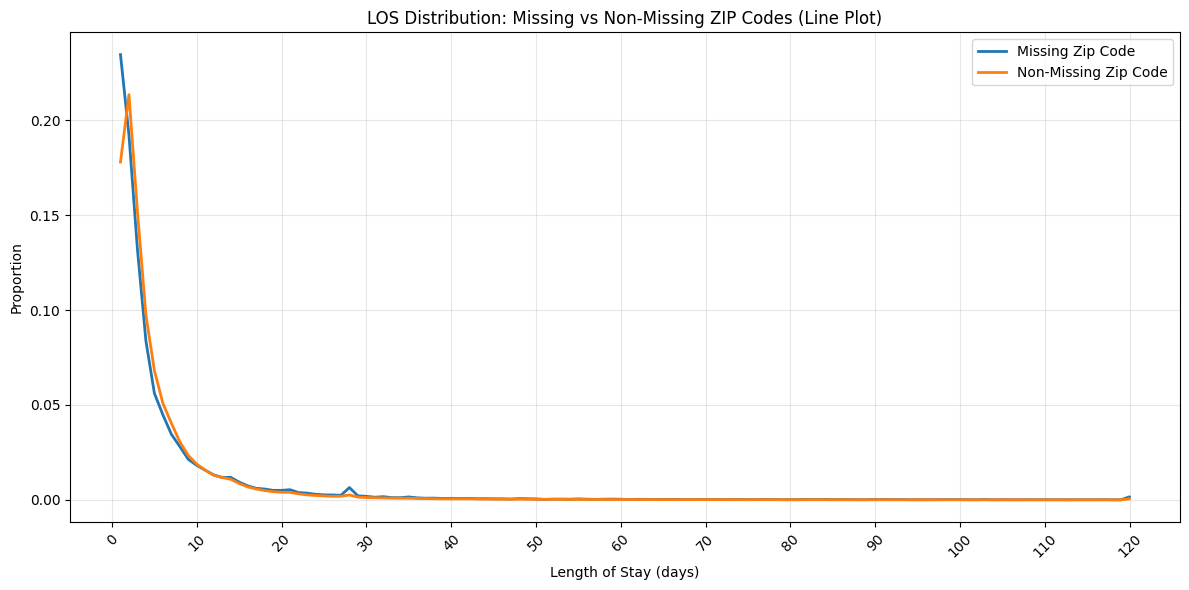

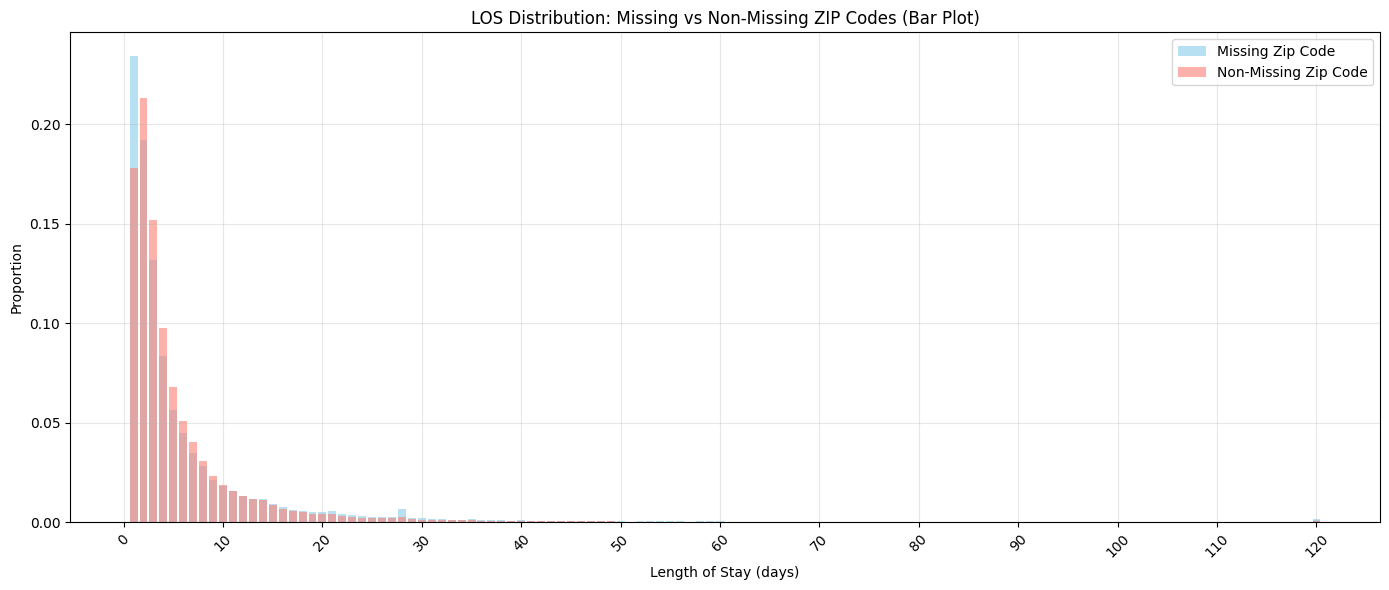

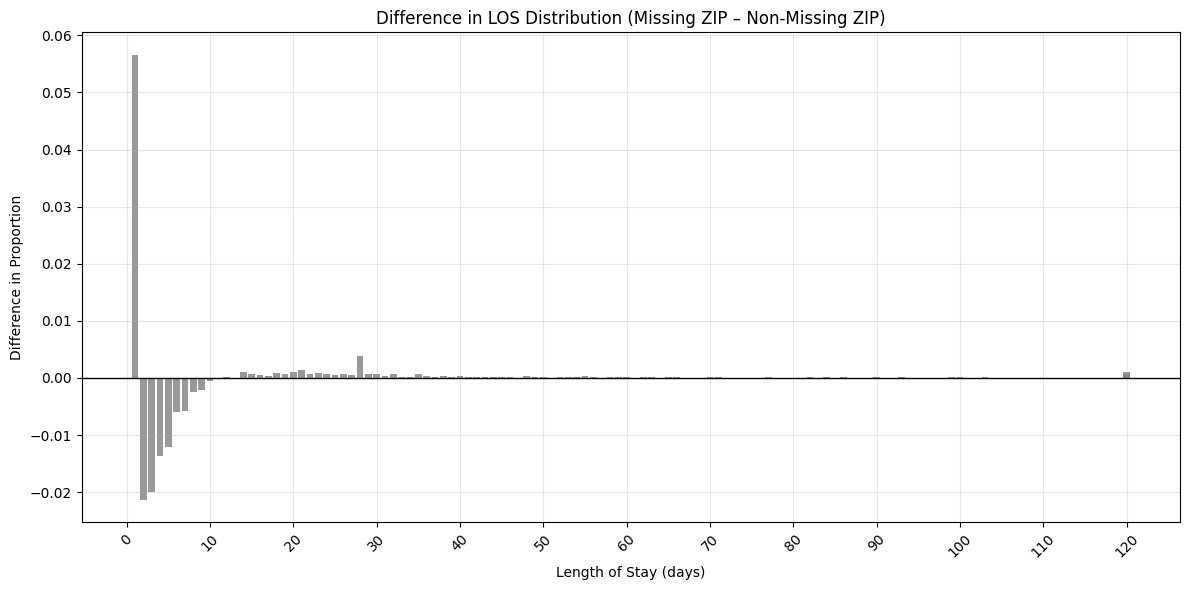

In [12]:
pd.set_option('display.max_rows', None)

missing_los = (
    missing_zip['Length of Stay']
    .value_counts(normalize=True)
    .rename("Missing Zip %")
)

nonmissing_los = (
    nonmissing_zip['Length of Stay']
    .value_counts(normalize=True)
    .rename("Non-Missing Zip %")
)

# Combine and clean index
los_compare = pd.concat([missing_los, nonmissing_los], axis=1).fillna(0)

# Convert index to integers (remove '+')
los_compare["LOS_int"] = (
    los_compare.index
    .astype(str)
    .str.replace("+", "", regex=False)
    .astype(int)
)

# Sort by LOS in case LOS_int is not ordered
los_compare = los_compare.sort_values("LOS_int")

# Line plot
plt.figure(figsize=(12, 6))
plt.plot(
    los_compare["LOS_int"], los_compare["Missing Zip %"],
    label="Missing Zip Code", linewidth=2
)
plt.plot(
    los_compare["LOS_int"], los_compare["Non-Missing Zip %"],
    label="Non-Missing Zip Code", linewidth=2
)

plt.xticks(
    ticks=range(0, los_compare["LOS_int"].max()+1, 10),
    rotation=45
)

plt.grid(alpha=0.3)
plt.xlabel("Length of Stay (days)")
plt.ylabel("Proportion")
plt.title("LOS Distribution: Missing vs Non-Missing ZIP Codes (Line Plot)")
plt.legend()
plt.tight_layout()
plt.show()

# Bar plot
plt.figure(figsize=(14, 6))
plt.bar(los_compare["LOS_int"], los_compare["Missing Zip %"],
        color='skyblue', alpha=0.6, label="Missing Zip Code")
plt.bar(los_compare["LOS_int"], los_compare["Non-Missing Zip %"],
        color='salmon', alpha=0.6, label="Non-Missing Zip Code")

plt.xticks(
    ticks=range(0, los_compare["LOS_int"].max()+1, 10),
    rotation=45
)

plt.grid(alpha=0.3)
plt.xlabel("Length of Stay (days)")
plt.ylabel("Proportion")
plt.title("LOS Distribution: Missing vs Non-Missing ZIP Codes (Bar Plot)")
plt.legend()
plt.tight_layout()
plt.show()

# Difference plot
los_compare["Difference"] = (
    los_compare["Missing Zip %"] -
    los_compare["Non-Missing Zip %"]
)

plt.figure(figsize=(12, 6))
plt.bar(los_compare["LOS_int"], los_compare["Difference"],
        color='gray', alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.xticks(
    ticks=range(0, los_compare["LOS_int"].max()+1, 10),
    rotation=45
)

plt.grid(alpha=0.3)
plt.xlabel("Length of Stay (days)")
plt.ylabel("Difference in Proportion")
plt.title("Difference in LOS Distribution (Missing ZIP – Non-Missing ZIP)")
plt.tight_layout()
plt.show()

In [13]:
# Remove entries that are missing zip code values
sparcs_combined = sparcs_combined.dropna(subset=['Zip Code'])

In [15]:
# Save new Parquet of cleaned sparcs combined
sparcs_combined.to_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_combined_clean_v1.parquet', index=False)

In [16]:
# Load sparcs combined clean v1
sparcs_combined_clean_v1 = pd.read_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_combined_clean_v1.parquet')

In [17]:
# Create a function to create mapping dict for {Facility Id: Name, and all codes: descriptions}
import logging

# Set up basic logger
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def create_all_code_mappings (df, code_desc_pairs, excel_output_path=None):
  """
  Creates a mapping dictionary for multiple code-description pairs,
  drops all description columns,
  logs progress and optionally exports to excel (one sheet per code/desc pair).

  Parameters
  ----------
  - df: pd.DataFrame
        DataFrame with code and description columns.
  - code_desc_pairs: list of tuples
        List of (code_column, description_column) pairs.
  - excel_output_path: str, optional
        Path to save the output Excel file.
  Returns
  ----------
  - tuple
        (mapping_dicts, updated_df)
  """

  df = df.copy()
  mapping_dicts = {}

  def process_single_mapping (df, code_col, desc_col):
    logger.info(f"Processing mapping: {code_col} -> {desc_col}")

    # Filter out empty of invalid entries
    valid_rows = df[(df[code_col].notna()) & (df[desc_col].notna()) & (df[code_col] != '')]

    # Create mapping dict
    mapping_dict = (
        valid_rows[[code_col, desc_col]]
        .drop_duplicates(subset=[code_col])
        .set_index(code_col)[desc_col]
        .to_dict()
    )

    # Drop description column
    df = df.drop(columns=[desc_col])

    logger.info(f"Mapping created: {len(mapping_dict)} unique codes")
    return mapping_dict, df

  # Process all code/description pairs
  for code_col, desc_col in code_desc_pairs:
    mapping_dict, df = process_single_mapping(df, code_col, desc_col)
    mapping_dicts[code_col] = mapping_dict

  # Export to excel if wanted, with sheet groupings by category
  if excel_output_path:
    logger.info(f"Exporting all mappings to Excel: {excel_output_path}")

    with pd.ExcelWriter(excel_output_path) as writer:
      for code_col, mapping in mapping_dicts.items():
        sheet_name = code_col.replace('code', '').strip().title()[:30]
        mapping_df = pd.DataFrame(list(mapping.items()), columns=['Code', 'Description'])
        mapping_df.to_excel(writer, sheet_name=sheet_name, index=False)

    logger.info("Excel export completed successfully")


  return mapping_dicts, df


# Using mapping_dicts function:
code_desc_pairs = [
    ("Permanent Facility Id", "Facility Name"),
    ("CCSR Diagnosis Code", "CCSR Diagnosis Description"),
    ("CCSR Procedure Code", "CCSR Procedure Description"),
    ("APR DRG Code", "APR DRG Description"),
    ("APR MDC Code", "APR MDC Description"),
    ("APR Severity of Illness Code", "APR Severity of Illness Description")
]

mappings, clean_df = create_all_code_mappings(
    df=sparcs_combined_clean_v1,
    code_desc_pairs=code_desc_pairs,
    excel_output_path='/content/sparcs_mappings.xlsx'
)


In [18]:
# Save updated clean_df (no description columns) as a new parquet
sparcs_cleaned_v2 = clean_df.copy()
sparcs_cleaned_v2.to_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v2.parquet', index=False)

#**Change Reporting of Payment Typology Columns**

In [4]:
# Load sparcs_cleaned_v2
sparcs_cleaned_v2 = pd.read_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v2.parquet')

In [5]:
# Get value counts in payment typology columns
for col in ['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']:
  print(f"Value Counts for {col}:")
  print(sparcs_cleaned_v2[col].value_counts(dropna=False))
  print("\n")

Value Counts for Payment Typology 1:
Payment Typology 1
Medicare                     1775903
Medicaid                     1251502
Private Health Insurance      601530
Blue Cross/Blue Shield        403119
Self-Pay                       61229
Managed Care, Unspecified      57198
Miscellaneous/Other            44160
Federal/State/Local/VA         40935
Department of Corrections       2834
None                             226
Name: count, dtype: int64


Value Counts for Payment Typology 2:
Payment Typology 2
None                         2264587
Medicaid                      826762
Medicare                      333777
Private Health Insurance      297494
Self-Pay                      255811
Blue Cross/Blue Shield        212895
Federal/State/Local/VA         24850
Managed Care, Unspecified      11150
Miscellaneous/Other            11124
Department of Corrections        186
Name: count, dtype: int64


Value Counts for Payment Typology 3:
Payment Typology 3
None                         3723609

In [6]:
# Define a function to change payment typology columns to binary values
def encode_payment_typologies(df, save_path="sparcs_cleaned_v3.parquet"):
  """
  Transform payment typology columns into binary indicator features and returns
  new dataframe, retaining the original.

  - Converts the three categorical payment typology columns
    ('Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3')
    into a set of binary columns.
  - Adds a numerical feature showing how many payers are present per row.
  - Deletes the original columns.
  - Saves a new cleaned dataframe to a parquet file.

  Parameters:
  - df: pd.DataFrame
      Input DataFrame with payment typology columns.

  - save_path: str, optional (default = "sparcs_cleaned_v3.parquet")
      Path to save the new cleaned DataFrame.

  Returns:
  - df_cleaned: pd.DataFrame
      DataFrame with binary payer columns and a 'num_payers' feature and
      original columns dropped.

  """

  # Create a copy df so original is unchanged
  df_cleaned = df.copy()

  # Identify payment typology columns
  payment_cols = ['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']

  # Get all unique payer types across all three columns
  unique_payers = pd.concat([df_cleaned[col] for col in payment_cols]).dropna().unique()

  # Create binary indicator for each unique payer type
  for payer in unique_payers:
    # Mark 1 if payer appears in any of the three payment typology columns, else mark 0
    df_cleaned[payer] = df_cleaned[payment_cols].eq(payer).any(axis=1).astype(int)

  # Add a feature counting how many payment typology fields are filled
  df_cleaned['Number of Payment Typologies'] = df_cleaned[payment_cols].notna().sum(axis=1)

  # Drop the original payment typology columns
  df_cleaned = df_cleaned.drop(columns=payment_cols)

  # Save the cleaned Dataframe as parquet
  df_cleaned.to_parquet(save_path, index=False)

  return df_cleaned

In [7]:
# Payment typology function usage
sparcs_cleaned_v3 = encode_payment_typologies(
    df=sparcs_cleaned_v2)

In [8]:
# Save sparcs_cleaned_v3 to drive as parquet
sparcs_cleaned_v3.to_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v3.parquet')

In [9]:
print(sparcs_cleaned_v3.columns)

Index(['Health Service Area', 'Hospital County', 'Permanent Facility Id',
       'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity',
       'Length of Stay', 'Type of Admission', 'Patient Disposition',
       'Discharge Year', 'CCSR Diagnosis Code', 'CCSR Procedure Code',
       'APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code',
       'APR Risk of Mortality', 'APR Medical Surgical Description',
       'Total Charges', 'Medicaid', 'Medicare', 'Private Health Insurance',
       'Self-Pay', 'Blue Cross/Blue Shield', 'Miscellaneous/Other',
       'Federal/State/Local/VA', 'Department of Corrections',
       'Managed Care, Unspecified', 'Number of Payment Typologies'],
      dtype='object')


In [10]:
sparcs_cleaned_v3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 30 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Health Service Area               object 
 1   Hospital County                   object 
 2   Permanent Facility Id             Int64  
 3   Age Group                         object 
 4   Zip Code                          object 
 5   Gender                            object 
 6   Race                              object 
 7   Ethnicity                         object 
 8   Length of Stay                    object 
 9   Type of Admission                 object 
 10  Patient Disposition               object 
 11  Discharge Year                    int64  
 12  CCSR Diagnosis Code               object 
 13  CCSR Procedure Code               object 
 14  APR DRG Code                      int64  
 15  APR MDC Code                      int64  
 16  APR Severity of Illness Code      in

In [ ]:
# Check value counts for length of stay
pd.set_option('display.max_rows', None)

los_counts = sparcs_cleaned_v3['Length of Stay'].value_counts()
print(los_counts)

pd.reset_option('display.max_rows')

In [12]:
# Convert LOS dtype to string for standardizing reporting
sparcs_cleaned_v3['Length of Stay'] = sparcs_cleaned_v3['Length of Stay'].astype('string')

# Convert any 120+ LOS values to 120 for ML
sparcs_cleaned_v3['Length of Stay'] = sparcs_cleaned_v3['Length of Stay'].apply(lambda x: '120' if str(x).startswith('120') else x)

# Convert LOS back to integer
sparcs_cleaned_v3['Length of Stay'] = sparcs_cleaned_v3['Length of Stay'].astype('int')

In [13]:
sparcs_cleaned_v3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 30 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Health Service Area               object 
 1   Hospital County                   object 
 2   Permanent Facility Id             Int64  
 3   Age Group                         object 
 4   Zip Code                          object 
 5   Gender                            object 
 6   Race                              object 
 7   Ethnicity                         object 
 8   Length of Stay                    int64  
 9   Type of Admission                 object 
 10  Patient Disposition               object 
 11  Discharge Year                    int64  
 12  CCSR Diagnosis Code               object 
 13  CCSR Procedure Code               object 
 14  APR DRG Code                      int64  
 15  APR MDC Code                      int64  
 16  APR Severity of Illness Code      in

In [14]:
sparcs_cleaned_v3.head()

,Health Service Area,Hospital County,Permanent Facility Id,Age Group,Zip Code,Gender,Race,Ethnicity,Length of Stay,Type of Admission,...,Medicaid,Medicare,Private Health Insurance,Self-Pay,Blue Cross/Blue Shield,Miscellaneous/Other,Federal/State/Local/VA,Department of Corrections,"Managed Care, Unspecified",Number of Payment Typologies
0,New York City,Bronx,3058,50-69,104,F,Other Race,Spanish/Hispanic,1,Emergency,...,1,0,0,0,0,0,0,0,0,1
1,New York City,Bronx,1168,30-49,104,M,Black/African American,Not Span/Hispanic,4,Emergency,...,1,0,0,0,0,0,0,0,0,1
2,New York City,Bronx,3058,50-69,104,M,Other Race,Not Span/Hispanic,4,Emergency,...,1,1,0,0,0,0,0,0,0,2
3,New York City,Bronx,1169,18-29,104,M,Black/African American,Not Span/Hispanic,5,Emergency,...,1,0,0,0,0,0,0,0,0,1
4,New York City,Bronx,1169,50-69,104,F,Other Race,Spanish/Hispanic,3,Emergency,...,1,1,0,0,0,0,0,0,0,2


In [15]:
# Save changes to sparcs_cleaned_v3 as new parquet: sparcs_cleaned_v4
sparcs_cleaned_v3.to_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v4.parquet', index=False)

In [3]:
# Read sparcs v4
sparcs_cleaned_v4 = pd.read_parquet('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v4.parquet')

In [4]:
# Change columns names for ease
rename_map = {
    'Health Service Area': 'health_service_area',
    'Hospital County': 'hospital_county',
    'Permanent Facility Id': 'facility_id',
    'Age Group': 'age_group',
    'Zip Code': 'zip_code',
    'Gender': 'gender',
    'Race': 'race',
    'Ethnicity': 'ethnicity',
    'Length of Stay': 'length_of_stay',
    'Type of Admission': 'admission_type',
    'Patient Disposition': 'disposition',
    'Discharge Year': 'discharge_year',
    'CCSR Diagnosis Code': 'ccsr_dx_code',
    'CCSR Procedure Code': 'ccsr_px_code',
    'APR MDC Code': 'apr_mdc_code',
    'APR DRG Code': 'apr_drg_code',
    'APR Severity of Illness Code': 'apr_severity_code',
    'APR Medical Surgical Description': 'apr_med_surg_desc',
    'APR Risk of Mortality': 'apr_mortality_risk',
    'Total Charges': 'total_charges',
    'Medicaid': 'payer_medicaid',
    'Medicare': 'payer_medicare',
    'Private Health Insurance': 'payer_private_insurance',
    'Self-Pay': 'payer_self_pay',
    'Blue Cross/Blue Shield': 'payer_blue_cross',
    'Miscellaneous/Other': 'payer_other',
    'Federal/State/Local/VA': 'payer_gov_va',
    'Department of Corrections': 'payer_corrections',
    'Managed Care, Unspecified': 'payer_managed_care',
    'Number of Payment Typologies': 'num_payment_types',
}

sparcs_cleaned_v4 = sparcs_cleaned_v4.rename(columns=rename_map)

In [5]:
sparcs_cleaned_v4.head()

,health_service_area,hospital_county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,admission_type,...,payer_medicaid,payer_medicare,payer_private_insurance,payer_self_pay,payer_blue_cross,payer_other,payer_gov_va,payer_corrections,payer_managed_care,num_payment_types
0,New York City,Bronx,3058,50-69,104,F,Other Race,Spanish/Hispanic,1,Emergency,...,1,0,0,0,0,0,0,0,0,1
1,New York City,Bronx,1168,30-49,104,M,Black/African American,Not Span/Hispanic,4,Emergency,...,1,0,0,0,0,0,0,0,0,1
2,New York City,Bronx,3058,50-69,104,M,Other Race,Not Span/Hispanic,4,Emergency,...,1,1,0,0,0,0,0,0,0,2
3,New York City,Bronx,1169,18-29,104,M,Black/African American,Not Span/Hispanic,5,Emergency,...,1,0,0,0,0,0,0,0,0,1
4,New York City,Bronx,1169,50-69,104,F,Other Race,Spanish/Hispanic,3,Emergency,...,1,1,0,0,0,0,0,0,0,2


In [6]:
sparcs_cleaned_v4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 30 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   health_service_area      object 
 1   hospital_county          object 
 2   facility_id              Int64  
 3   age_group                object 
 4   zip_code                 object 
 5   gender                   object 
 6   race                     object 
 7   ethnicity                object 
 8   length_of_stay           int64  
 9   admission_type           object 
 10  disposition              object 
 11  discharge_year           int64  
 12  ccsr_dx_code             object 
 13  ccsr_px_code             object 
 14  apr_drg_code             int64  
 15  apr_mdc_code             int64  
 16  apr_severity_code        int64  
 17  apr_mortality_risk       object 
 18  apr_med_surg_desc        object 
 19  total_charges            float64
 20  payer_medicaid           int64  
 21  payer_me

In [7]:
# Fix dtypes:
categorical_int_cols = [
    'facility_id',
    'apr_drg_code',
    'apr_mdc_code',
    'apr_severity_code'
]

for col in categorical_int_cols:
  sparcs_cleaned_v4[col] = sparcs_cleaned_v4[col].astype("object")

#**Check for Missing Values**

In [8]:
import pandas as pd

#Check for missing values, the % missing and display as a table
missing_data = []
for col in sparcs_cleaned_v4.columns:
  missing_values = sparcs_cleaned_v4[col].isna().sum()
  missing_percent = (missing_values / len(sparcs_cleaned_v4) * 100).round(2)
  missing_data.append({'Column': col, 'Missing Values': missing_values, 'Missing %': missing_percent})

missing_table = pd.DataFrame(missing_data)
display(missing_table)

,Column,Missing Values,Missing %
0,health_service_area,0,0.00
1,hospital_county,0,0.00
2,facility_id,0,0.00
3,age_group,0,0.00
4,zip_code,0,0.00
5,gender,0,0.00
6,race,0,0.00
7,ethnicity,0,0.00
8,length_of_stay,0,0.00
9,admission_type,0,0.00


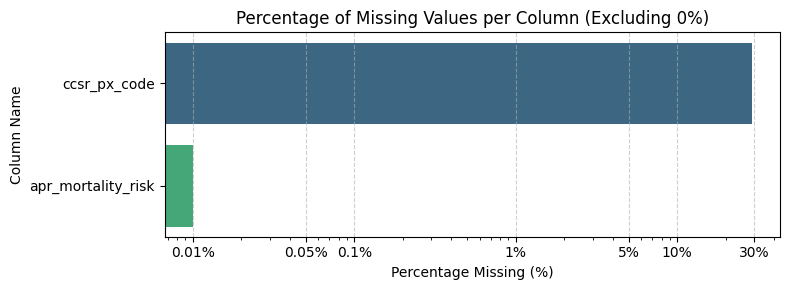

In [9]:
#Visualize Missing Data
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for columns with actual missing data
missing_table_filtered = missing_table[missing_table['Missing %'] > 0]

if not missing_table_filtered.empty:
    # Sort values for better visualization
    missing_table_filtered = missing_table_filtered.sort_values(by='Missing %', ascending=False)

    # Generate a bar chart visualizing these missing percentages
    plt.figure(figsize=(8, 3))

    sns.barplot(
        x='Missing %',
        y='Column',
        data=missing_table_filtered,
        palette='viridis',
        hue='Column',
        legend=False
        )
    plt.title('Percentage of Missing Values per Column (Excluding 0%)')
    plt.xscale("log")
    plt.xticks(
        [0.01, 0.05, 0.1, 1, 5, 10, 30],
        ["0.01%", "0.05%", "0.1%", "1%", "5%", "10%", "30%"]
    )
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Column Name')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No columns with missing values to display.")
#CCSR Procedure Code has a significant percentage of missing values, approximately 29.08%. This suggests that for a considerable portion of the records, a procedure code or description was not recorded.
#APR Severity of Illness Description and APR Risk of Mortality have a very small percentage of missing values, both around 0.01%. This indicates that these columns are almost complete, with only a handful of entries lacking this information.

#Statistical Summary and Visualizing Outliers

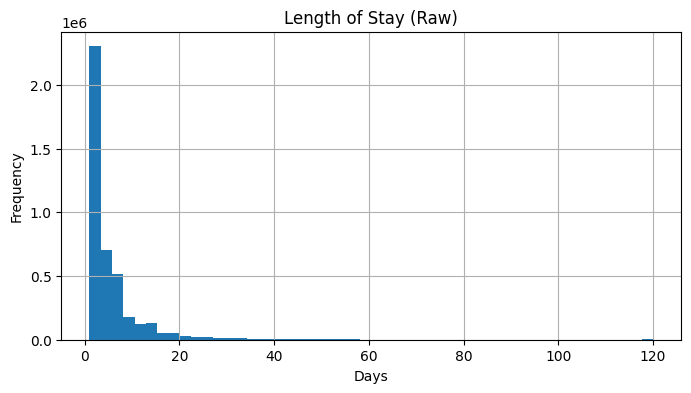

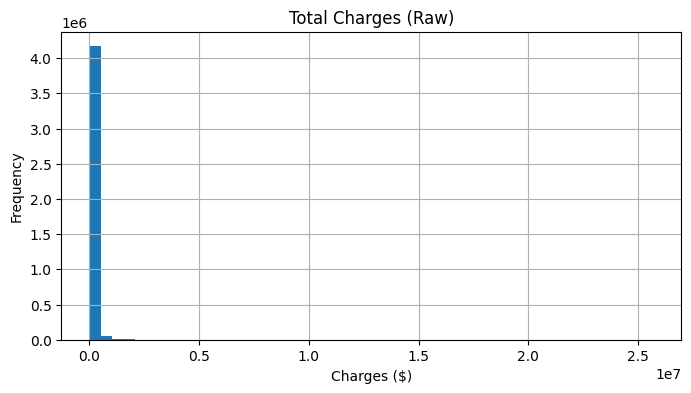

In [10]:
# Distribution LOS
plt.figure(figsize=(8,4))
sparcs_cleaned_v4['length_of_stay'].hist(bins=50)
plt.title("Length of Stay (Raw)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

# Distribution Total Charges
plt.figure(figsize=(8,4))
sparcs_cleaned_v4['total_charges'].hist(bins=50)
plt.title("Total Charges (Raw)")
plt.xlabel("Charges ($)")
plt.ylabel("Frequency")
plt.show()

In [11]:
#Numeric and Category Outlier Checks
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

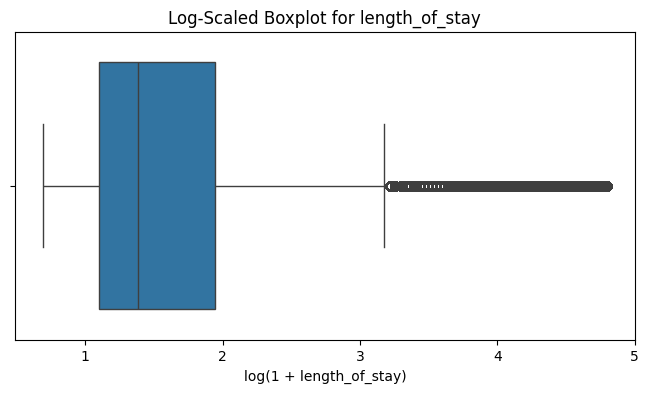

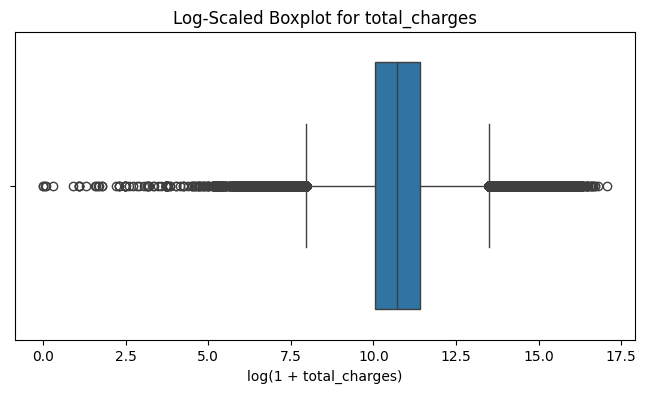

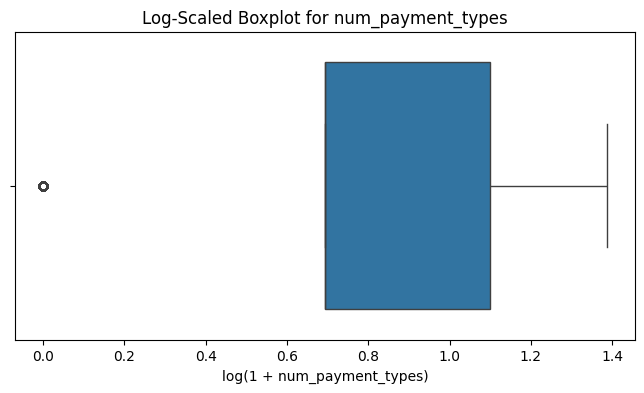

IQR Outlier Summary:
length_of_stay: 417073 outliers (9.84%)
total_charges: 378694 outliers (8.93%)
num_payment_types: 0 outliers (0.00%)


In [12]:
# Numeric Outliers
numeric_outlier_cols = [
    'length_of_stay',
    'total_charges',
    'num_payment_types'
]

#Boxplot Overview for Numeric Features
for col in numeric_outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=np.log1p(sparcs_cleaned_v4[col]))
    plt.xlabel(f"log(1 + {col})")
    plt.title(f'Log-Scaled Boxplot for {col}')
    plt.show()

#IQR Based Outlier Counts
def iqr_outlier_bounds(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

print("IQR Outlier Summary:")
for col in numeric_outlier_cols:
    lower, upper = iqr_outlier_bounds(sparcs_cleaned_v4, col)
    outliers = ((sparcs_cleaned_v4[col] < lower) | (sparcs_cleaned_v4[col] > upper)).sum()
    pct = (outliers / len(sparcs_cleaned_v4)) * 100
    print(f"{col}: {outliers} outliers ({pct:.2f}%)")

#**Interpreting These Plots:**

###**LOS Boxplot**



*   Most patients stay 1–10 days
*   The median LOS (center of the box) is low — probably 2–3 days

*   There is a long tail extending to LOS 60–120+ days
*   These long stays show up as dots in the right tail, even after log-scaling

*   Log scale compresses large values, the boxplot is now readable

**Interpretation**
These “outlier” long stays are expected:
ICU cases

*   Complications
*   Older patients
*   Rehab / long-term care
*   Transitions
*   Severe trauma
*   Medical complexity

###**Total Charges Boxplot**



*   The middle 50% of patients have charges around log(1 + charge) ≈ 9-11
→ this corresponds to approx 8k-60k dollars
*   There are many very high-charge cases
→ 200k, 500k,
1M, etc
*   These appear as right-tail dots - NORMAL b/c hospital charges can be so expensive

**Interpretation**
Total charges almost always incredibly skewed in hospital data.

Common reasons:
*   Transplant
*   Trauma
*   Surgery + complications
*   Extended ICU stays
*   Neonatal ICU
*   Specialist drugs

###**Num Payment Types Boxplot**
No outliers here - b/c patient can only have either 1/2/3 payment typologies.





##**Transform LOS: Calculate skew for raw, log transformed, and Yeo-Johnson transformed**

In [13]:
# Perform LOS Transformations - Check distribution to determine best method for ML
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Copy dataset
df = sparcs_cleaned_v4.copy()

# 1. Log transform
df['los_log']=np.log1p(df['length_of_stay'])

# 2. Sqrt transform
df['los_sqrt'] = np.sqrt(df['length_of_stay'])

# 3. Yeo-Johnson transform
pt = PowerTransformer(method='yeo-johnson')
df['los_yj'] = pt.fit_transform(df[['length_of_stay']])

In [14]:
print("Skewness Comparison:")
print("Raw LOS:           ", df['length_of_stay'].skew())
print("log(LOS):          ", df['los_log'].skew())
print("sqrt(LOS):         ", df['los_sqrt'].skew())
print("Yeo-Johnson LOS:   ", df['los_yj'].skew())


Skewness Comparison:
Raw LOS:            6.150893228457668
log(LOS):           0.9950686875877651
sqrt(LOS):          2.3877764399433947
Yeo-Johnson LOS:    0.108688226471295


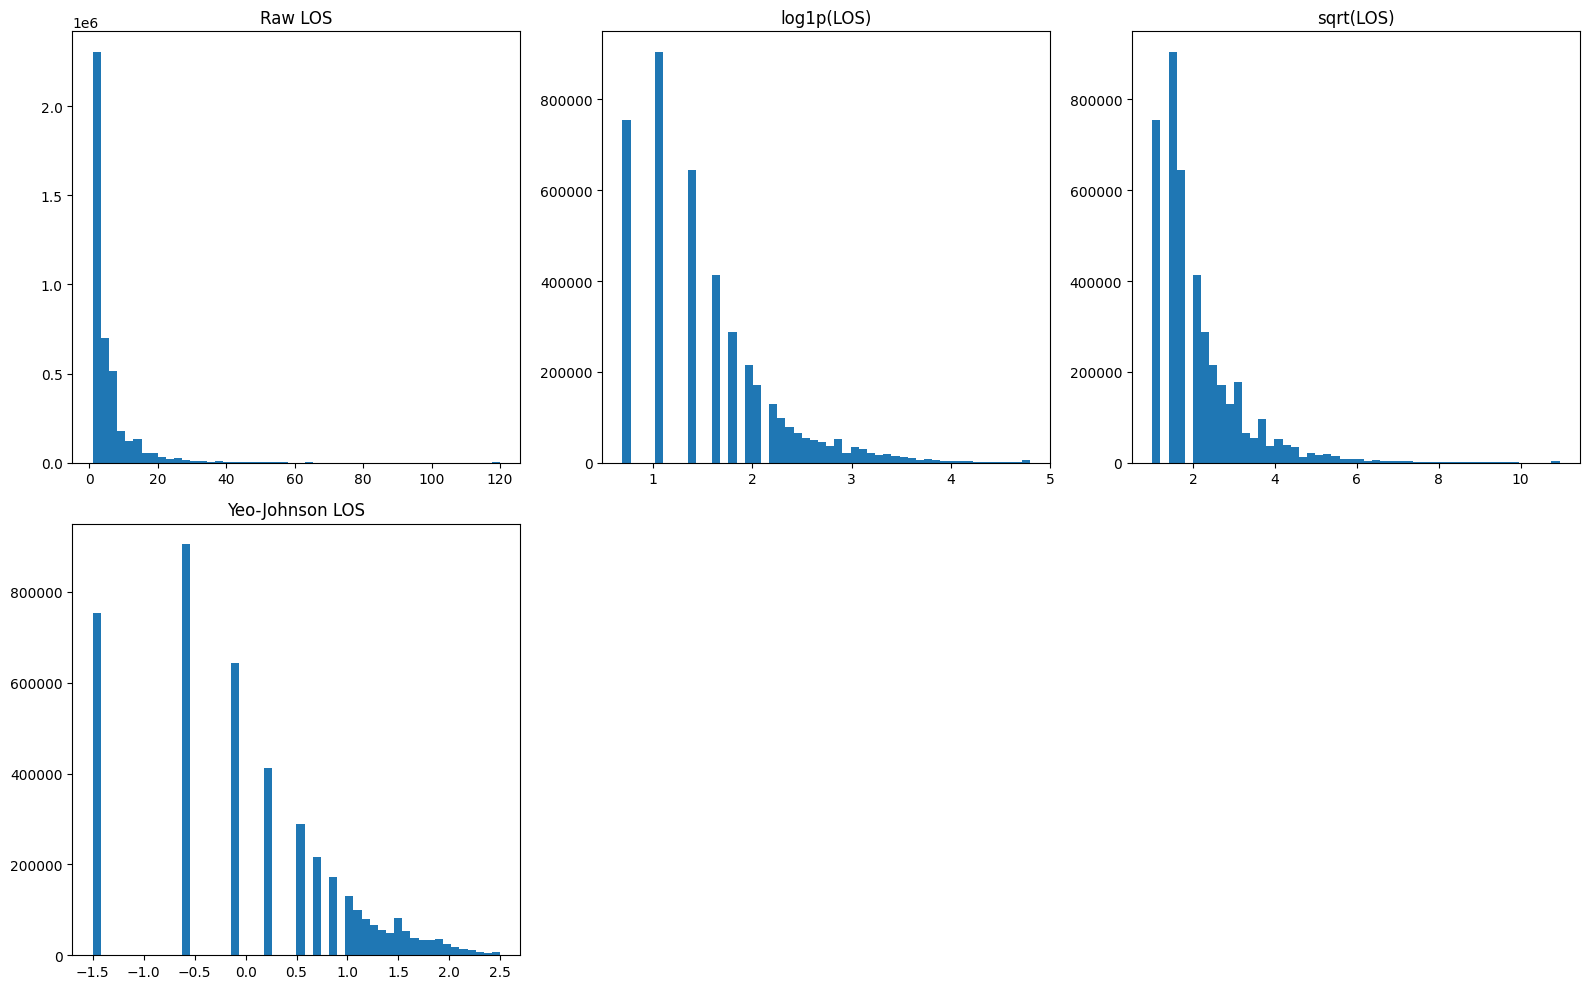

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

# SAFE HIST PLOTTER TO AVOID BLANK PLOTS
def safe_hist(ax, series, title, bins=50):
    # Drop NaN + non-numeric
    numeric = pd.to_numeric(series, errors='coerce').dropna()
    ax.hist(numeric, bins=bins)
    ax.set_title(title)

# Raw LOS
safe_hist(axs[0,0], df['length_of_stay'], "Raw LOS")

# log(LOS)
safe_hist(axs[0,1], df['los_log'], "log1p(LOS)")

# sqrt(LOS)
safe_hist(axs[0,2], df['los_sqrt'], "sqrt(LOS)")

# Yeo-Johnson LOS
safe_hist(axs[1,0], df['los_yj'], "Yeo-Johnson LOS")

# Turn off the two unused subplots
axs[1,1].axis("off")
axs[1,2].axis("off")

plt.tight_layout()
plt.show()

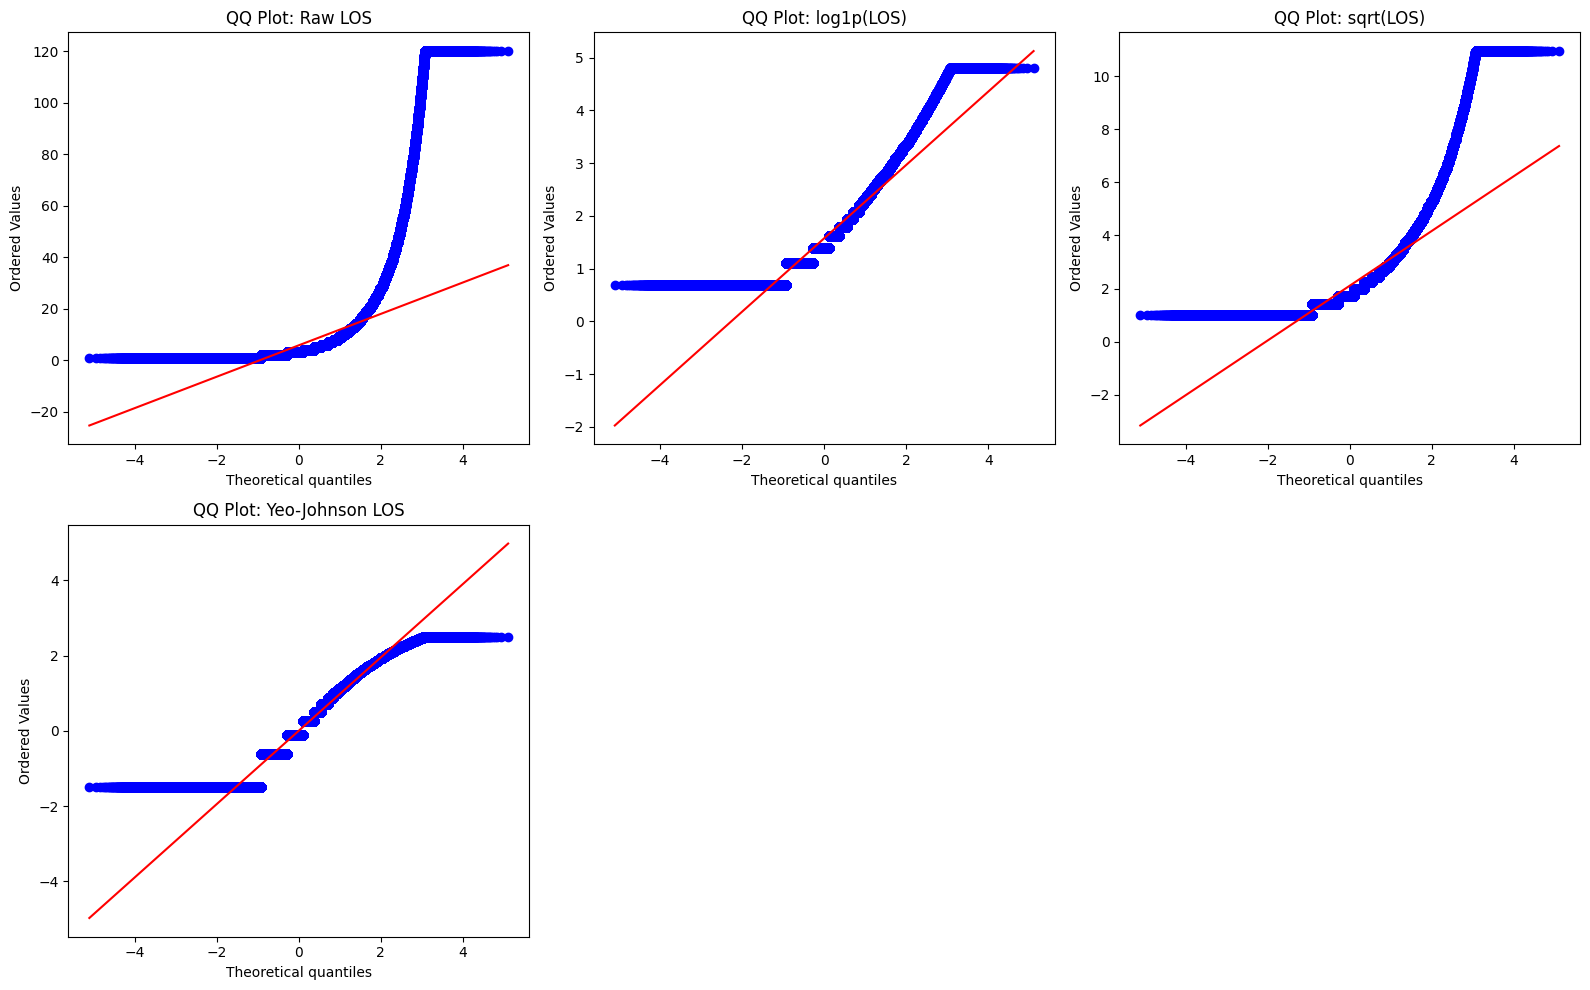

In [16]:
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

# SAFE QQ-PLOTTER FUNCTION
def safe_qqplot(ax, series, title):
    # Drop non-numeric + NaN values
    numeric = pd.to_numeric(series, errors='coerce').dropna()

    # Only plot if we have enough values
    if len(numeric) > 10:
        stats.probplot(numeric, dist="norm", plot=ax)
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, "Insufficient data", ha='center')
        ax.set_title(title)
        ax.axis("off")  # Avoid misleading empty axes


# --- PLOTS ---
safe_qqplot(axs[0,0], df['length_of_stay'], "QQ Plot: Raw LOS")
safe_qqplot(axs[0,1], df['los_log'], "QQ Plot: log1p(LOS)")
safe_qqplot(axs[0,2], df['los_sqrt'], "QQ Plot: sqrt(LOS)")
safe_qqplot(axs[1,0], df['los_yj'], "QQ Plot: Yeo-Johnson LOS")

# Hide unused subplots
axs[1,1].axis("off")
axs[1,2].axis("off")

plt.tight_layout()
plt.show()

##**Further Inspect Categorical Data**

In [17]:
#Categorical Data Quality Check
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical columns
categorical_cols = sparcs_cleaned_v4.select_dtypes(include=['object']).columns
print("Categorical Columns:", list(categorical_cols))

#Frequency counts for all categorical columns to show distribution and spot rare cases
for col in categorical_cols:
    print(f"\n{col} value counts (%):")
    print((sparcs_cleaned_v4[col].value_counts(normalize=True) * 100).round(2))
    print("-" * 40)

Categorical Columns: ['health_service_area', 'hospital_county', 'facility_id', 'age_group', 'zip_code', 'gender', 'race', 'ethnicity', 'admission_type', 'disposition', 'ccsr_dx_code', 'ccsr_px_code', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_code', 'apr_mortality_risk', 'apr_med_surg_desc']

health_service_area value counts (%):
health_service_area
New York City          45.30
Long Island            16.48
Hudson Valley          11.12
Western NY              6.55
Capital/Adirondacks     6.51
Finger Lakes            6.48
Central NY              6.31
Southern Tier           1.25
Name: proportion, dtype: float64
----------------------------------------

hospital_county value counts (%):
hospital_county
Kings             9.11
New York          8.96
Nassau            8.83
Manhattan         8.68
Queens            8.54
Suffolk           7.66
Bronx             7.50
Westchester       5.71
Erie              5.18
Monroe            4.90
Onondaga          3.27
Albany            2.81
Richmond    

In [ ]:
# @title
#DO NOT CODE YET THIS IS JUST WHAT I THINK THE CATEGORICAL OUTLIER CLEAN UP SHOULD LOOK LIKE BUT IM NOT SURE
#i made the code wrong so it wont work if u run all just in case :D (missing closing brackets)
#if you guys agree this looks good then go ahead and run it :) i will make us a clean ML ready csv file including all of these changes

# Convert LOS back to numeric (it shouldn't be categorical)
sparcs_cleaned_v3['Length of Stay'] = pd.to_numeric(sparcs_cleaned_v3['Length of Stay'], errors='coerce')

# Merge rare categories
sparcs_cleaned_v3 = merge_rare_categories(sparcs_cleaned_v3, 'Hospital County', threshold=0.01)
sparcs_cleaned_v3 = merge_rare_categories(sparcs_cleaned_v3, 'Patient Disposition', threshold=0.005)
sparcs_cleaned_v3['Ethnicity'] = sparcs_cleaned_v3['Ethnicity'].replace({'Multi-ethnic': 'Other'})
sparcs_cleaned_v3['Race'] = sparcs_cleaned_v3['Race'].replace({'Multi-racial': 'Other Race'})
sparcs_cleaned_v3['Gender'] = sparcs_cleaned_v3['Gender'].replace({'U': 'Unknown'})

# Drop high-cardinality columns for now (you can revisit later if you plan embeddings or NLP)
parcs_cleaned_v3 = sparcs_cleaned_v3.drop(columns=[
    'Facility Name',
    'Zip Code',
    'CCSR Diagnosis Code', 'CCSR Diagnosis Description',
    'CCSR Procedure Code', 'CCSR Procedure Description',
    'APR DRG Description'

#**Final Changes to DF**

In [19]:
model_full = sparcs_cleaned_v4.copy()
# Convert dtypes in columns
cols_convert = ['facility_id', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_code']

for col in cols_convert:
  model_full[col] = model_full[col].astype(str).astype('object')

# Replace None in apr_mortality_risk
model_full['apr_mortality_risk'] = model_full['apr_mortality_risk'].replace(
    [None, 'None'],
    'Undetermined'
)

# convert "None" to "No procedure" for ccsr_px_code
model_full['ccsr_px_code'] = model_full['ccsr_px_code'].replace(
    [None, 'None'],
    'No procedure'
)

##**Drop Total Charges and Patient Disposition**
###Both highly related to LOS, will cause leakage in the model:
  - Total charges: high costs = longer LOS
  - Disposition: at discharge, implies long LOS if patient transferred for example


In [20]:
# Drop total_charges, log_total_charges, disposition (because inform LOS)
model_full.drop(columns=['total_charges', 'disposition'], errors='ignore', inplace=True)

#**Save Final DF (For now)**
- I think maybe we should try first to use CatBoost, because we dont have to worry about one-hot encoding categorical variables

In [22]:
# Save v5
model_full.to_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_data_v1.feather')